# 01 - Sketch-conditioned diffusion

A face sketch constrains spatial structure but leaves color, illumination and much of the surface texture unspecified. The task is therefore formulated as conditional generation: given a sketch $s$, learn a distribution $p_\theta(x_0\mid s)$ over corresponding photographs, rather than a single deterministic reconstruction.

The model operates directly on RGB images at $256\times256$. A conditional U-Net predicts a denoising target at each noise level, and repeated denoising maps a Gaussian sample to a photograph. This notebook develops the forward process, network parameterization and training objective used by the original U-Net; notebook 03 retains the same diffusion formulation with a revised architecture.

The probabilistic formulation is discussed more broadly in [Luo, *Understanding Diffusion Models: A Unified Perspective*](https://arxiv.org/abs/2208.11970).

In [1]:
from pathlib import Path
from copy import deepcopy
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

torch.manual_seed(42)

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from models.diffusion import Diffusion
from models.unet import UNet
from utils.data import make_dataloader
from utils.visualization import (
    plot_losses,
    show_forward_diffusion,
    show_generation_grid,
    show_pairs,
)

## Paired data and geometric augmentation

Training uses aligned sketch-photograph pairs $(s,x_0)$. A geometric transformation $A$ is sampled once per pair and applied to both images, giving $(A(s),A(x_0))$. This preserves the correspondence between facial landmarks while varying their positions in the image. Independent transformations would instead introduce contradictory spatial supervision.

The augmentation combines rotation within $\pm12^\circ$, translation up to 10% per axis, scaling between 0.9 and 1.1, a random crop and horizontal reflection. Validation uses deterministic resizing. The dataset counts and paired examples below characterize the available supervision before training.

In [2]:
manifest_path = ROOT / "data/processed/pairs.csv"

pairs = pd.read_csv(manifest_path)
summary = pairs.groupby(["dataset", "split"]).size().reset_index(name="pairs")
display(summary.pivot(index="dataset", columns="split", values="pairs").fillna(0).astype(int))

split,test,train,val
dataset,,,
cufs_kaggle,0,100,0
face_sketch,0,100,0
fs2k,1046,1058,0
person_face_sketches,679,20655,1000


In [3]:
print(f"total paired examples: {len(pairs):,}")

total paired examples: 24,638


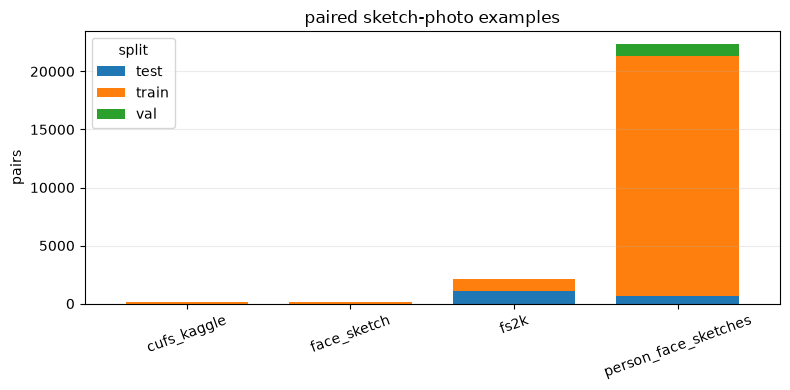

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = summary.pivot(index="dataset", columns="split", values="pairs").fillna(0)
plot_df.plot(kind="bar", stacked=True, ax=ax, width=0.75)
ax.set_title("paired sketch-photo examples")
ax.set_ylabel("pairs")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

training pairs before repeat: 21,913


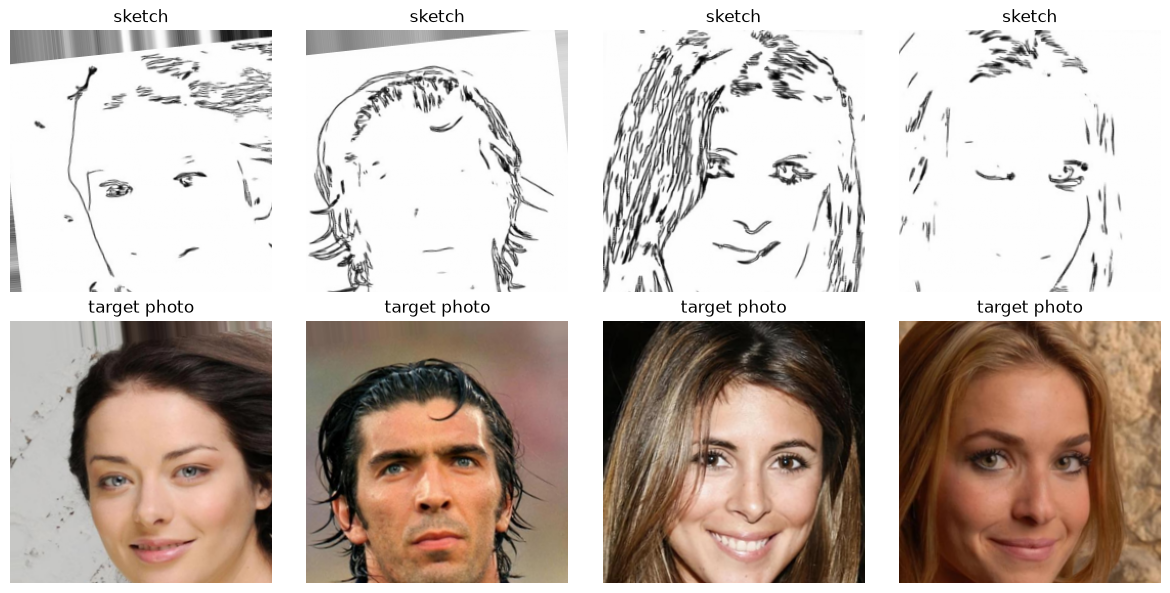

In [5]:
train_loader = make_dataloader(
    manifest_path,
    split="train",
    image_size=256,
    batch_size=8,
    repeat=1,
    shuffle=True,
    num_workers=2,
    random_transform=True,
    affine=True,
)

preview_loader = make_dataloader(
    manifest_path,
    split="val",
    image_size=256,
    batch_size=8,
    repeat=1,
    shuffle=False,
    num_workers=2,
    random_transform=False,
)

sketches, photos = next(iter(train_loader))
print(f"training pairs before repeat: {train_loader.dataset.num_pairs:,}")
show_pairs(sketches, photos, n=4)
plt.show()

## Forward diffusion and the reverse model

Let $x_0$ denote a clean photograph and $\beta_t$ the variance introduced at step $t$. The forward process is a fixed Gaussian Markov chain,

$$q(x_t\mid x_{t-1})=\mathcal N\!\left(\sqrt{\alpha_t}\,x_{t-1},\beta_t I\right),
\qquad \alpha_t=1-\beta_t.$$

Composing these transitions gives a marginal that can be sampled directly:

$$q(x_t\mid x_0)=\mathcal N\!\left(\sqrt{\bar\alpha_t}\,x_0,(1-\bar\alpha_t)I\right),
\qquad \bar\alpha_t=\prod_{j=1}^{t}\alpha_j,$$

$$x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\epsilon,
\qquad \epsilon\sim\mathcal N(0,I).$$

This closed form permits training at a randomly chosen noise level without simulating the preceding steps. The implementation uses 1,000 levels with a cosine schedule, for which the final marginal is approximately standard Gaussian.

The generative model reverses this construction while conditioning on the sketch:

$$p_\theta(x_{0:T}\mid s)=p(x_T)\prod_{t=1}^{T}p_\theta(x_{t-1}\mid x_t,s),
\qquad p(x_T)=\mathcal N(0,I).$$

Integrating out $x_{1:T}$ defines $p_\theta(x_0\mid s)$. Here $q$ specifies a known corruption process; the parameters $\theta$ belong to the learned reverse model.

device(type='cuda')

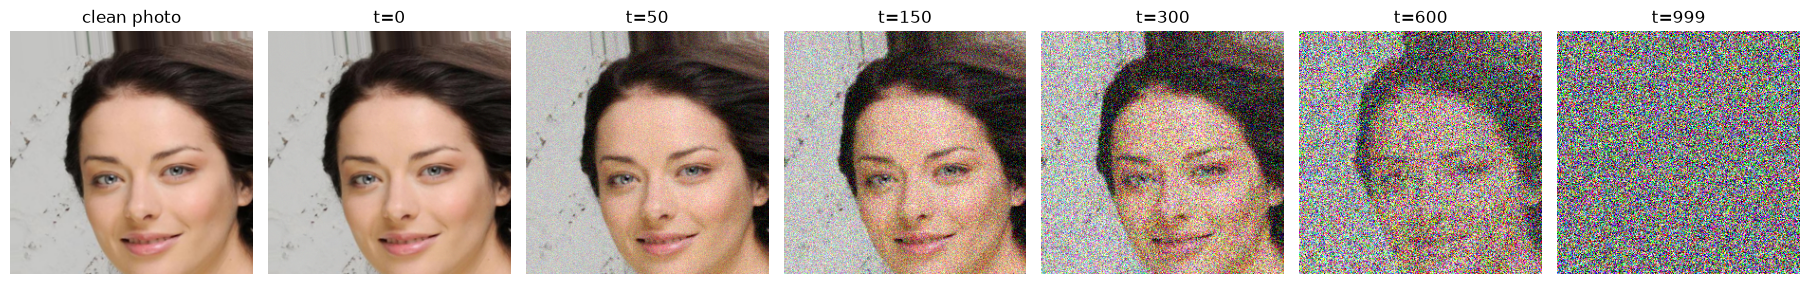

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
diffusion = Diffusion(timesteps=1000, device=device, schedule="cosine")
show_forward_diffusion(diffusion, photos.to(device), steps=(0, 50, 150, 300, 600, 999))
device

## Conditional U-Net

The network receives the four-channel tensor $[s,x_t]$: one sketch channel and three noisy RGB channels. A sinusoidal timestep embedding enters each residual block, allowing the same network to represent different denoising regimes. A separate sketch encoder supplies spatial features at five resolutions; these are added to the corresponding image-encoder features.

The U-Net combines local detail through skip connections with self-attention at the bottleneck. Its output is an RGB-shaped velocity estimate $v_\theta(x_t,s,t)$, not a photograph or an evaluated probability density. The conversion from this estimate to a clean image is determined by the diffusion parameterization below.

In [7]:
model = UNet(
    n_channels=4,
    n_classes=3,
    base_channels=48,
    time_emb_dim=192,
    sketch_channels=1,
    use_attention=True,
).to(device)
ema_model = deepcopy(model).eval()

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")

params_m = sum(p.numel() for p in model.parameters()) / 1e6
print(f"parameters: {params_m:.2f}M")

parameters: 22.78M


## Velocity prediction and the training objective

Write $a_t=\sqrt{\bar\alpha_t}$ and $b_t=\sqrt{1-\bar\alpha_t}$, so that $a_t^2+b_t^2=1$. The velocity target is the complementary linear combination of the clean image and noise:

$$\begin{bmatrix}x_t\\v\end{bmatrix}
=\begin{bmatrix}a_t&b_t\\-b_t&a_t\end{bmatrix}
\begin{bmatrix}x_0\\\epsilon\end{bmatrix}.$$

The transformation is orthogonal. Its inverse gives both quantities required for sampling from a single network prediction:

$$\hat x_0=a_tx_t-b_tv_\theta(x_t,s,t),
\qquad \hat\epsilon=b_tx_t+a_tv_\theta(x_t,s,t).$$

Training minimizes velocity error together with an auxiliary reconstruction term,

$$\mathcal L(\theta)=\mathbb E_{(s,x_0),t,\epsilon}
\left[\operatorname{MSE}(v_\theta,v)+0.25\,\operatorname{MAE}(\hat x_0,x_0)\right],
\qquad t\sim\mathcal U\{1,\ldots,T\}.$$

Both errors are averaged over image elements. The first term fits the denoising field across noise levels; the second penalizes deviations from the paired photograph in image space. This is the implemented denoising objective with an auxiliary loss, rather than the full variational likelihood bound.

AdamW updates the model for 12 epochs with batches of eight. An exponential moving average, $\bar\theta\leftarrow0.999\bar\theta+0.001\theta$, supplies the weights used for generation.

In [8]:
def update_ema(ema, source, decay=0.999):
    with torch.no_grad():
        for ema_p, p in zip(ema.parameters(), source.parameters()):
            ema_p.mul_(decay).add_(p, alpha=1 - decay)
        for ema_b, b in zip(ema.buffers(), source.buffers()):
            ema_b.copy_(b)


history = []
checkpoint_dir = ROOT / "checkpoints"
checkpoint_dir.mkdir(exist_ok=True)
model.train()

for epoch in range(1, 13):
    pbar = tqdm(train_loader, desc=f"epoch {epoch}")
    for step, (sketches, photos) in enumerate(pbar, start=1):
        sketches = sketches.to(device, non_blocking=True)
        photos = photos.to(device, non_blocking=True)

        t = diffusion.sample_timesteps(photos.size(0))
        noisy_photos, noise = diffusion.add_noise(photos, t)
        target_v = diffusion.v_target(photos, noise, t)

        with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
            pred_v = model(torch.cat([sketches, noisy_photos], dim=1), t)
            pred_x0 = diffusion.predict_x0_from_v(noisy_photos, t, pred_v)
            # L = mean((v_theta - v)^2) + 0.25 * mean(|x_0_hat - x_0|).
            loss = F.mse_loss(pred_v, target_v) + 0.25 * F.l1_loss(pred_x0, photos)

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        update_ema(ema_model, model)

        history.append(float(loss.detach().cpu()))
        pbar.set_postfix(loss=f"{history[-1]:.4f}")
        if step % 100 == 0:
            print(f"epoch {epoch}/12 | step {step}/{len(train_loader)} | mean loss {sum(history[-100:]) / 100:.4f}", flush=True)

    torch.save(
        {
            "model_name": "UNet",
            "epoch": epoch,
            "model": model.state_dict(),
            "ema": ema_model.state_dict(),
            "history": history,
            "model_args": {
                "n_channels": 4,
                "n_classes": 3,
                "base_channels": 48,
                "time_emb_dim": 192,
                "sketch_channels": 1,
                "use_attention": True,
            },
        },
        checkpoint_dir / "diffusion_sketch_faces_aug.pt",
    )
    print(f"epoch {epoch}/12 saved | total updates {len(history)}", flush=True)

epoch 1/12 | step 100/2739 | mean loss 0.4763
epoch 1/12 | step 200/2739 | mean loss 0.1928
epoch 1/12 | step 300/2739 | mean loss 0.1649
epoch 1/12 | step 400/2739 | mean loss 0.1344
epoch 1/12 | step 500/2739 | mean loss 0.1206
epoch 1/12 | step 600/2739 | mean loss 0.1202
epoch 1/12 | step 700/2739 | mean loss 0.1089
epoch 1/12 | step 800/2739 | mean loss 0.1105
epoch 1/12 | step 900/2739 | mean loss 0.1100
epoch 1/12 | step 1000/2739 | mean loss 0.1037
epoch 1/12 | step 1100/2739 | mean loss 0.1008
epoch 1/12 | step 1200/2739 | mean loss 0.0931
epoch 1/12 | step 1300/2739 | mean loss 0.0926
epoch 1/12 | step 1400/2739 | mean loss 0.0946
epoch 1/12 | step 1500/2739 | mean loss 0.0898
epoch 1/12 | step 1600/2739 | mean loss 0.0857
epoch 1/12 | step 1700/2739 | mean loss 0.0914
epoch 1/12 | step 1800/2739 | mean loss 0.0848
epoch 1/12 | step 1900/2739 | mean loss 0.0873
epoch 1/12 | step 2000/2739 | mean loss 0.0819
epoch 1/12 | step 2100/2739 | mean loss 0.0908
epoch 1/12 | step 2200

Non-fatal PyTorch DataLoader worker-cleanup warnings occurred during this run. All 12 epochs and 32,868 updates completed.


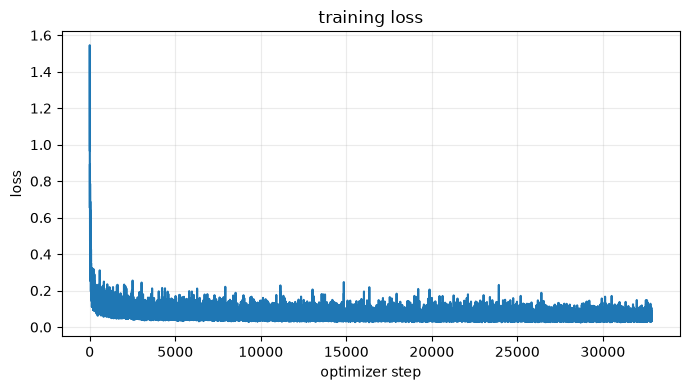

In [9]:
plot_losses(history)
plt.show()

## Generation with DDIM

Generation starts from $x_T\sim\mathcal N(0,I)$ and uses the EMA denoiser on a sequence of 60 decreasing noise levels. For $\eta=0$, a DDIM transition from $t$ to $u<t$ is

$$x_u=\sqrt{\bar\alpha_u}\,\hat x_0+\sqrt{1-\bar\alpha_u}\,\hat\epsilon.$$

The implementation clips $\hat x_0$ to the image range before this update. No additional noise is sampled along the trajectory, so the initial Gaussian draw and the sketch determine the result. The panel compares these generated samples with their paired photographs; notebook 02 examines the trajectory and the effects of varying each input separately.

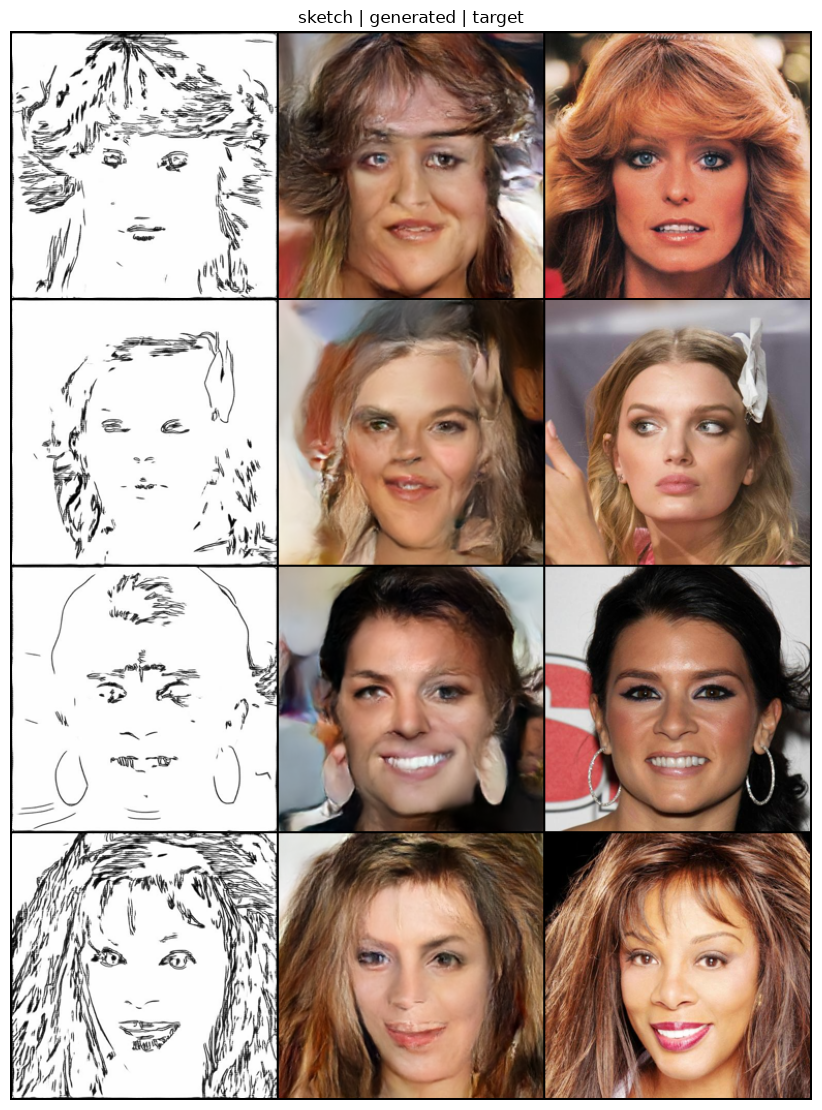

In [10]:
ema_model.eval()
val_sketches, val_photos = next(iter(preview_loader))
with torch.no_grad():
    generated = diffusion.ddim_sample(
        ema_model,
        val_sketches[:4].to(device),
        steps=60,
        eta=0.0,
        noise=torch.randn(4, 3, *val_photos.shape[-2:], generator=torch.Generator().manual_seed(123)).to(device),
    ).cpu()
show_generation_grid(val_sketches[:4], generated, val_photos[:4], n=4)
plt.show()